In [2]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

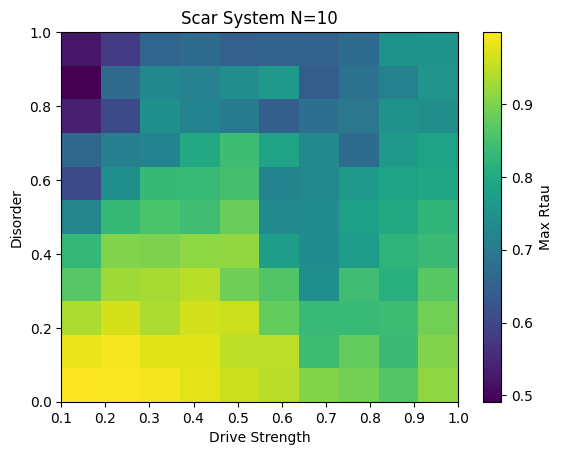

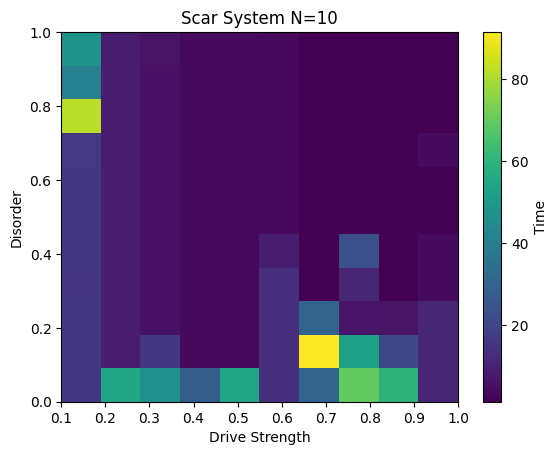

In [ ]:
N = 10
wd = 0.642570281124498
tlist = np.linspace(0, 200, 400)
dlist = np.linspace(0, 1, 11)
alist = np.linspace(0.1, 1, 10)
maxRtau = []
maxRtau_time = []

H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
basisLen = len(basisList)
for d in dlist:
    temp = []
    temp_time = []
    for a in alist:
        diag_vals = np.random.uniform(-d, d, basisLen)
        diag_vals -= np.mean(diag_vals)
        diagLocation = list(range(basisLen))
        H_anharm = csr_matrix((diag_vals, (diagLocation, diagLocation)), shape=(basisLen, basisLen))
        H_anharm = qt.Qobj(H_anharm)

        Hscar = H0 + H_anharm
        deigvals, deigstates = Hscar.eigenstates()
        band = deigvals[-1] - deigvals[0]

        args = {"A": a, "omega": wd}
        H = qt.QobjEvo([Hscar, [H1, coeff]], args=args)
        psi_t = qt.sesolve(H, deigstates[0], tlist, e_ops=[Hscar])

        Rtau = np.real(psi_t.expect[0] - psi_t.expect[0][0]) / band
        temp.append(np.max(Rtau))
        temp_time.append(np.argmax(Rtau) * 0.5)
    maxRtau.append(temp)
    maxRtau_time.append(temp_time)

plt.imshow(maxRtau,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis')
plt.colorbar(label="Max Rtau")
plt.title(f"Scar System N={N}")
plt.ylabel("Disorder")
plt.xlabel("Drive Strength")
plt.show()

plt.imshow(maxRtau_time,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis')
plt.colorbar(label="Time")
plt.title(f"Scar System N={N}")
plt.ylabel("Disorder")
plt.xlabel("Drive Strength")
plt.show()

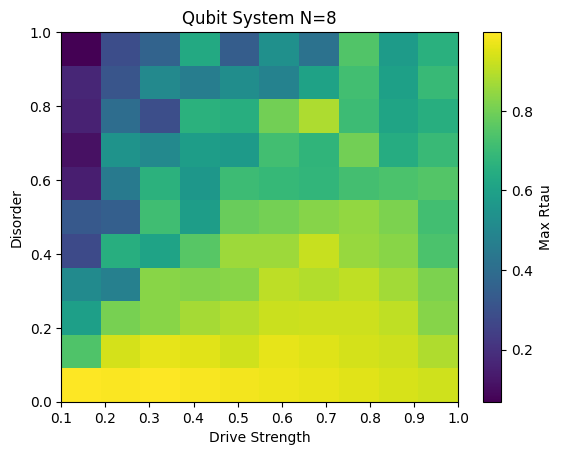

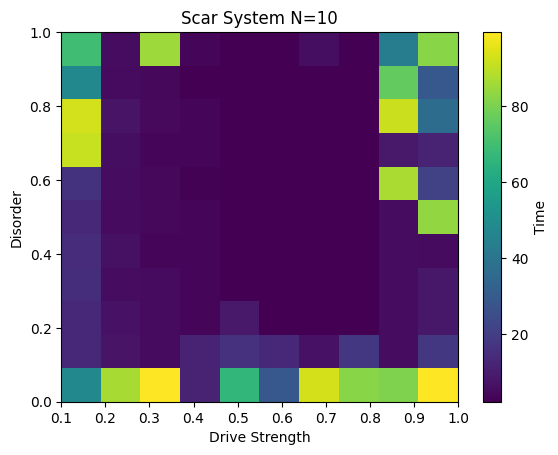

In [ ]:
qN = 8
wm = 1.0
qmaxRtau = []
qmaxRtau_time = []

for d in dlist:
    temp = []
    temp_time = []
    for a in alist:
        qH0, qH1, wm = get_random_qubit_ham(N, detuning=d, wm=wm)
        qeigvals, qeigstates = qH0.eigenstates()
        qband = qeigvals[-1] - qeigvals[0]

        qargs = {"A": a, "omega": wm}
        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, qeigstates[0], tlist, e_ops=[qH0])

        Rtau = np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qband
        temp.append(np.max(Rtau))
        temp_time.append(np.argmax(Rtau) * 0.5)
    qmaxRtau.append(temp)
    qmaxRtau_time.append(temp_time)

plt.imshow(qmaxRtau,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis')
plt.colorbar(label="Max Rtau")
plt.title(f"Qubit System N={qN}")
plt.ylabel("Disorder")
plt.xlabel("Drive Strength")
plt.show()

plt.imshow(qmaxRtau_time,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis')
plt.colorbar(label="Time")
plt.title(f"Scar System N={N}")
plt.ylabel("Disorder")
plt.xlabel("Drive Strength")
plt.show()